# Minimize a nonlinear function of two variables with no constraints

Do imports.

In [1]:
import numpy as np
from qpsolvers import solve_qp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import sympy as sym

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)

Define and plot the function

$$ f(x_1, x_2) = (a - x_1)^2 + b (x_2 - x_1^2)^2 $$

with parameters $a=1$ and $b=1$. This function has one global minimum at

$$ x = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} 1 \\ 1 \end{bmatrix}. $$

It is called a *Rosenbrock function* and is often used for examples when talking about nonlinear minimization because the minimum is in a shallow bowl and so the use of line search is important.

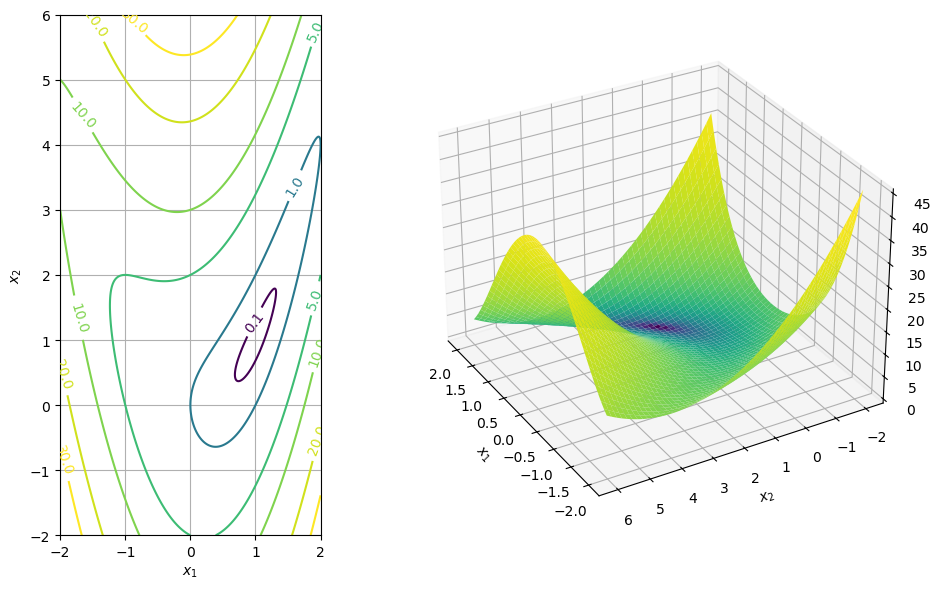

In [2]:
# Coefficients
a = 1
b = 1

# Variables
x1, x2 = sym.symbols('x1, x2')

# Function
f_sym = (a - x1)**2 + b * (x2 - x1**2)**2
f_batch = sym.lambdify([x1, x2], f_sym)
f = lambda x: f_batch(*x)

# Plot
# - Sample on uniform grid
x1_bnds = [-2, 2]
x2_bnds = [-2, 6]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
# - Compute function value at each sample
F = f_batch(X1, X2)
# - Plot function
fig = plt.figure(figsize=(10, 6))
ax2d = fig.add_subplot(1, 2, 1)
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)
ax2d.set_aspect('equal')
ax2d.grid()
ax3d.plot_surface(X1, X2, F, norm='log', cmap='viridis', vmin=0., vmax=30.)
ax3d.azim = 150
ax3d.elev = 30
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax3d.set_xlabel(r'$x_1$')
ax3d.set_ylabel(r'$x_2$')
fig.tight_layout()
plt.show()

Define functions that compute the gradient and hessian of $f(x)$ with respect to $x$.

In [3]:
# Gradient
f_x_sym = sym.simplify(sym.Matrix([f_sym]).jacobian([x1, x2]).T)
f_x = lambda x: sym.lambdify([x1, x2], f_x_sym)(*x).flatten()

# Hessian
f_xx_sym = sym.simplify(f_x_sym.jacobian([x1, x2]))
f_xx = lambda x: sym.lambdify([x1, x2], f_xx_sym)(*x)

# Display
display(Markdown(r'$\nabla_x f(x)' + f' = {sym.latex(f_x_sym)}$'))
display(Markdown(r'$\nabla_{xx}^2 f(x)' + f' = {sym.latex(f_xx_sym)}$'))

$\nabla_x f(x) = \left[\begin{matrix}4 x_{1} \left(x_{1}^{2} - x_{2}\right) + 2 x_{1} - 2\\- 2 x_{1}^{2} + 2 x_{2}\end{matrix}\right]$

$\nabla_{xx}^2 f(x) = \left[\begin{matrix}12 x_{1}^{2} - 4 x_{2} + 2 & - 4 x_{1}\\- 4 x_{1} & 2\end{matrix}\right]$

Visualize backtracking line search for gradient descent direction.

found an acceptable alpha = 0.2500


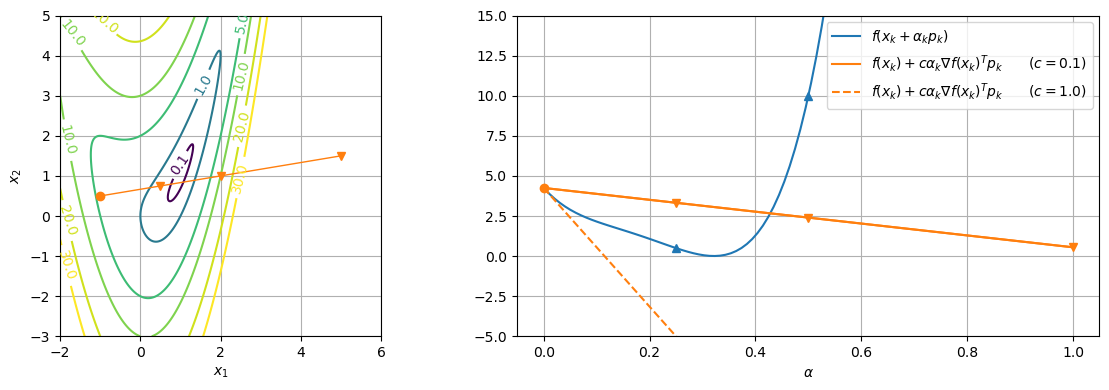

In [4]:
# Initial guess
x = np.array([-1., 0.5])

# Parameters
c = 0.1
rho = 0.5

# Descent direction (negative gradient)
grad_f = f_x(x)
p = -grad_f

# Compute cost on uniform grid
x1_bnds = [-2, 6]
x2_bnds = [-3, 5]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)

# Compute cost (actual and predicted) along descent direction
alpha = np.linspace(0, 1, 100)
a = []
b = []
b_1 = []
for alpha_i in alpha:
    a.append(f(x + alpha_i * p))
    b.append(f(x) + c * alpha_i * np.dot(grad_f, p))
    b_1.append(f(x) + alpha_i * np.dot(grad_f, p))

# Create plot
fig, (ax2d, axls) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)
ax2d.plot([x[0], x[0] + p[0]], [x[1], x[1] + p[1]], '-', color='C1', linewidth=1)
ax2d.plot(x[0], x[1], '.', color='C1', markersize=12)
axls.plot(alpha, a, label=r'$f(x_k + \alpha_k p_k)$')
axls.plot(alpha, b, '-', color='C1')
axls.plot(alpha, b, '-', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=0.1)$')
axls.plot(alpha, b_1, '--', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=1.0)$')
axls.plot(alpha[0], b[0], '.', color='C1', markersize=12)

# Visualize backtracking line search
alpha = 1.
no_progress= True
for j in range(10):
    x_new = x + alpha * p
    ax2d.plot(x_new[0], x_new[1], 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x) + c * alpha * np.dot(grad_f, p), 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x + alpha * p), '^', color='C0', markersize=6)
    if f(x + alpha * p) <= f(x) + c * alpha * np.dot(grad_f, p):
        no_progress = False
        break
    alpha *= rho
if no_progress:
    print('found no acceptable alpha')
else:
    print(f'found an acceptable alpha = {alpha:6.4f}')

# Make plot look good
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
axls.legend(loc='upper right')
axls.grid()
axls.set_xlabel(r'$\alpha$')
axls.set_ylim(-5, 15)
plt.show()

Visualize backtracking line search for Newton step direction.

found an acceptable alpha = 1.0000


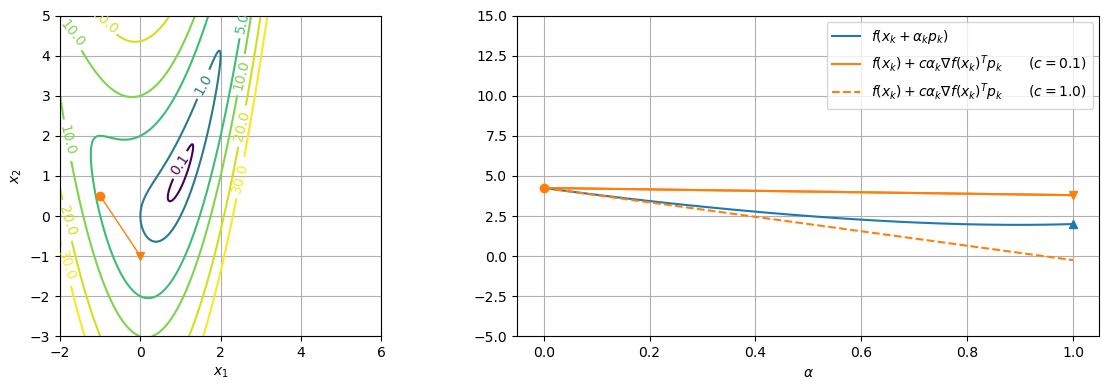

In [5]:
# Initial guess
x = np.array([-1., 0.5])

# Parameters
c = 0.1
rho = 0.5

# Descent direction (Newton)
grad_f = f_x(x)
hess_f = f_xx(x)
p = np.linalg.solve(hess_f, -grad_f) # <-- this may fail!

# Compute cost on uniform grid
x1_bnds = [-2, 6]
x2_bnds = [-3, 5]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)

# Compute cost (actual and predicted) along descent direction
alpha = np.linspace(0, 1, 100)
a = []
b = []
b_1 = []
for alpha_i in alpha:
    a.append(f(x + alpha_i * p))
    b.append(f(x) + c * alpha_i * np.dot(grad_f, p))
    b_1.append(f(x) + alpha_i * np.dot(grad_f, p))

# Create plot
fig, (ax2d, axls) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)
ax2d.plot([x[0], x[0] + p[0]], [x[1], x[1] + p[1]], '-', color='C1', linewidth=1)
ax2d.plot(x[0], x[1], '.', color='C1', markersize=12)
axls.plot(alpha, a, label=r'$f(x_k + \alpha_k p_k)$')
axls.plot(alpha, b, '-', color='C1')
axls.plot(alpha, b, '-', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=0.1)$')
axls.plot(alpha, b_1, '--', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=1.0)$')
axls.plot(alpha[0], b[0], '.', color='C1', markersize=12)

# Visualize backtracking line search
alpha = 1.
no_progress= True
for j in range(10):
    x_new = x + alpha * p
    ax2d.plot(x_new[0], x_new[1], 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x) + c * alpha * np.dot(grad_f, p), 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x + alpha * p), '^', color='C0', markersize=6)
    if f(x + alpha * p) <= f(x) + c * alpha * np.dot(grad_f, p):
        no_progress = False
        break
    alpha *= rho
if no_progress:
    print('found no acceptable alpha')
else:
    print(f'found an acceptable alpha = {alpha:6.4f}')

# Make plot look good
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
axls.legend(loc='upper right')
axls.grid()
axls.set_xlabel(r'$\alpha$')
axls.set_ylim(-5, 15)
plt.show()

In order for the Newton step to be a descent direction at $x_k$, we require that the Hessian of $f$ at $x_k$ be positive definite:

$$ \nabla_{xx}^2 f(x_k) \succ 0. $$

For functions of one variable (i.e., if $x_k \in \R$), this condition is equivalent to required the second derivative of $f$ at $x_k$ to be positive:

$$ \dfrac{\partial^2 f(x_k)}{\partial x^2} > 0, $$

as we have seen before. Remember that "positive" and "positive definite" mean different things — the matrix $M \in \R^{n \times n}$ is called *positive definite* if

$$ x^T M x > 0 \qquad \text{for all} \qquad x \in \R^n \qquad \text{such that} \qquad x \neq 0.$$

The consequences for us are the same in $\R^n$ as in $\R$, however. If the Hessian is positive definite, then the quadratic approximation to $f$ at $x_k$ looks like a bowl (with a minimum). If not, then the quadratic approximation to $f$ at $x_k$ looks like something else — for example, a hill (with a maximum) or a saddle (with neither a maximum nor a minimum).

This happens when $(x_1, x_2) = (-1, 2)$, as we see below. Notice that the cost *increases* rather than decreases in the direction $p_k$.

found no acceptable alpha


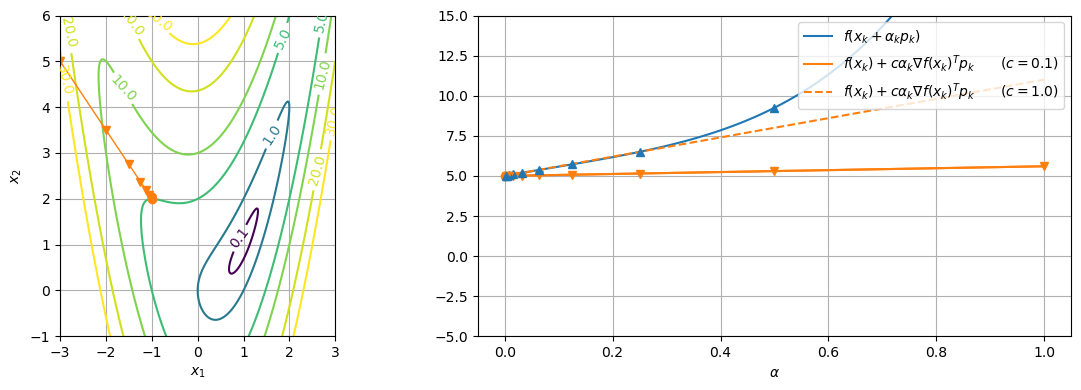

In [6]:
# Initial guess
x = np.array([-1.0, 2.0])

# Parameters
c = 0.1
rho = 0.5

# Descent direction (Newton)
grad_f = f_x(x)
hess_f = f_xx(x)
p = np.linalg.solve(hess_f, -grad_f) # <-- this may fail!

# Compute cost on uniform grid
x1_bnds = [-3, 3]
x2_bnds = [-1, 6]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)

# Compute cost (actual and predicted) along descent direction
alpha = np.linspace(0, 1, 100)
a = []
b = []
b_1 = []
for alpha_i in alpha:
    a.append(f(x + alpha_i * p))
    b.append(f(x) + c * alpha_i * np.dot(grad_f, p))
    b_1.append(f(x) + alpha_i * np.dot(grad_f, p))

# Create plot
fig, (ax2d, axls) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)
ax2d.plot([x[0], x[0] + p[0]], [x[1], x[1] + p[1]], '-', color='C1', linewidth=1)
ax2d.plot(x[0], x[1], '.', color='C1', markersize=12)
axls.plot(alpha, a, label=r'$f(x_k + \alpha_k p_k)$')
axls.plot(alpha, b, '-', color='C1')
axls.plot(alpha, b, '-', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=0.1)$')
axls.plot(alpha, b_1, '--', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=1.0)$')
axls.plot(alpha[0], b[0], '.', color='C1', markersize=12)

# Visualize backtracking line search
alpha = 1.
no_progress= True
for j in range(10):
    x_new = x + alpha * p
    ax2d.plot(x_new[0], x_new[1], 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x) + c * alpha * np.dot(grad_f, p), 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x + alpha * p), '^', color='C0', markersize=6)
    if f(x + alpha * p) <= f(x) + c * alpha * np.dot(grad_f, p):
        no_progress = False
        break
    alpha *= rho
if no_progress:
    print('found no acceptable alpha')
else:
    print(f'found an acceptable alpha = {alpha:6.4f}')

# Make plot look good
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
axls.legend(loc='upper right')
axls.grid()
axls.set_xlabel(r'$\alpha$')
axls.set_ylim(-5, 15)
plt.show()

We *could* fix this problem by choosing the gradient descent direction rather than the Newton step direction, like we did when $x \in \R$. However, this approach is harder to extend to minimization with constraints. An alternative is to **regularize** the Hessian (also called "Hessian modification") by adding a multiple of the identity matrix.

$$ H = \nabla_{xx}^2 f(x_k) + \mu I $$

for some $\mu > 0$. Even if

$$ \nabla_{xx}^2 f(x_k) \nsucc 0 $$

it will always be the case that

$$ H \succ 0 $$

for sufficiently large $\mu$. One simple way to find such a $\mu$ is to begin by trying some small value (e.g., $\mu = 10^{-6}$) and then increasing $\mu$ by a factor of $10$ at each iteration, stopping when $H$ is positive definite. This approach relies, of course, on being able to check if $H$ is positive definite. One way to do this is to find the eigenvalues of $H$. It is a fact that $H \succ 0$ if and only if all eigenvalues of $H$ are strictly positive.

In [7]:
x = [-1.0, 2.0]
hess_f = f_xx(x)

for mu in [0., 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1]:
    H = hess_f + mu * np.eye(len(x))
    eigs = np.linalg.eigvalsh(H)    # <-- we can use this instead of eigvals
                                    #     because hess_f is symmetric — we want
                                    #     to use it because it's more efficient
                                    #     and more numerically stable
    pd_str = ' : positive definite' if np.all(eigs > 0) else ''
    print(f'mu = {mu:7.4f} : eigs = [{eigs[0]:8.4f}, {eigs[1]:8.4f} ]{pd_str}')

mu =  0.0000 : eigs = [ -0.4721,   8.4721 ]
mu =  0.0001 : eigs = [ -0.4720,   8.4722 ]
mu =  0.0010 : eigs = [ -0.4711,   8.4731 ]
mu =  0.0100 : eigs = [ -0.4621,   8.4821 ]
mu =  0.1000 : eigs = [ -0.3721,   8.5721 ]
mu =  1.0000 : eigs = [  0.5279,   9.4721 ] : positive definite
mu = 10.0000 : eigs = [  9.5279,  18.4721 ] : positive definite


It is slow (and numerically unstable) to compute eigenvalues, however. An alternative is to attempt a **Cholesky factorization** of $H$. This factorization has the form

$$ H = L L^T $$

for some lower triangular matrix $L$ with positive diagonal entries. It is a fact that $H$ has a Cholesky factorization if and only if $H$ is positive definite. If you try and succeed, then $H \succ 0$. Otherwise, $H \nsucc 0$.

In [8]:
x = np.array([-1.0, 2.0])
hess_f = f_xx(x)

for mu in [0., 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1]:
    H = hess_f + mu * np.eye(len(x))
    try:
        np.linalg.cholesky(H)
        pd_str = ' : positive definite'
    except np.linalg.LinAlgError:
        pd_str = ''
    print(f'mu = {mu:7.4f}{pd_str}')

mu =  0.0000
mu =  0.0001
mu =  0.0010
mu =  0.0100
mu =  0.1000
mu =  1.0000 : positive definite
mu = 10.0000 : positive definite


Be careful! It is possible for the Cholesky factorization to succeed but for $H$ to still be near-singular (i.e., ill-conditioned) and so for `np.linalg.solve(H, -grad_f)` to still fail. This is something we can address by putting the solve inside a `try` statement along with the factorization.

In [9]:
x = np.array([-1.0, 1.5])
hess_f = f_xx(x)
grad_f = f_x(x)
H = hess_f

for mu in [0., 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1]:
    H = hess_f + mu * np.eye(len(x))
    pd_str = ''
    try:
        np.linalg.cholesky(H)
        pd_str += ' : positive definite'
        p = np.linalg.solve(H, -grad_f)
        pd_str += ' : can solve for descent direction'
    except np.linalg.LinAlgError:
        pass
    print(f'mu = {mu:7.4f}{pd_str}')

mu =  0.0000 : positive definite
mu =  0.0001 : positive definite : can solve for descent direction
mu =  0.0010 : positive definite : can solve for descent direction
mu =  0.0100 : positive definite : can solve for descent direction
mu =  0.1000 : positive definite : can solve for descent direction
mu =  1.0000 : positive definite : can solve for descent direction
mu = 10.0000 : positive definite : can solve for descent direction


Be careful! It is also possible for *both* the factorization *and* the solve to succeed but still get a bad result — in this example, a very large step $p_k$. This large step would cause backtracking line search to fail, because we wouldn't backtrack far enough in 10 iterations (or whatever) to get an acceptable step size.

In [10]:
x = np.array([-1.0, 1.5])
hess_f = f_xx(x)
grad_f = f_x(x)
mu = 1e-6
H = hess_f + mu * np.eye(len(x))

# Cholesky (succeeds)
L = np.linalg.cholesky(H)

# Solve (succeeds... but look at the result!)
p = np.linalg.solve(H, -grad_f)
with np.printoptions(precision=4):
    print(f'p = {p}')

print('')

# Show the norm of the step we would take after 0, 10, 25
# iterations of backtracking line search with rho = 0.5
print(f'|alpha * p| = {np.linalg.norm((0.5**0) * p):6.4e}  <-- for alpha = 0.5^0  = {0.5**0:6.4e} (full step)')
print(f'|alpha * p| = {np.linalg.norm((0.5**10) * p):6.4e}  <-- for alpha = 0.5^10 = {0.5**10:6.4e}')
print(f'|alpha * p| = {np.linalg.norm((0.5**25) * p):6.4e}  <-- for alpha = 0.5^25 = {0.5**25:6.4e}')

p = [  800000.1201 -1599999.9401]

|alpha * p| = 1.7889e+06  <-- for alpha = 0.5^0  = 1.0000e+00 (full step)
|alpha * p| = 1.7469e+03  <-- for alpha = 0.5^10 = 9.7656e-04
|alpha * p| = 5.3312e-02  <-- for alpha = 0.5^25 = 2.9802e-08


There are ways to address this problem as well, for example through the use of what is called a **trust region**. However, at this point, let's acknowledge that it is non-trivial to implement a robust solver for nonlinear minimization problems, and simply increase the number of iterations we allow for backtracking line search.

Let's apply what we have learned.

regularized with mu = 1e-06
found an acceptable alpha after 19 iterations of backtracking line search with c = 0.1 and rho = 0.5
       alpha = 1.9073e-06
  alpha * p  = [1.5259, -3.0518]
 |alpha * p| = 3.4120e+00


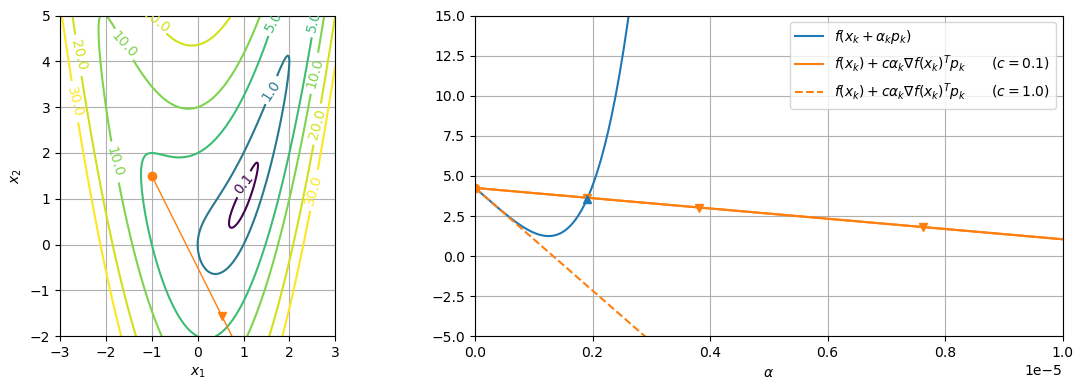

In [11]:
# Initial guess
x = np.array([-1.0, 1.5])

# Parameters
c = 0.1
rho = 0.5
delta = 1e-6
max_cond = 1e4

# Descent direction (Newton) with regularization
# - Get gradient and hessian just like before
grad_f = f_x(x)
hess_f = f_xx(x)
# - Regularize hessian if necessary to make it positive definite
H = hess_f.copy()
mu = delta
while True:
    try:
        # Attempt a Cholesky factorization - if it fails, then H is not
        # positive definite and we need to add more regularization
        L_chol = np.linalg.cholesky(H)
        # Attempt to solve for the descent direction - if it fails, then
        # H is ill-conditioned and we need to add more regularization
        p = np.linalg.solve(H, -grad_f)
        break
    except np.linalg.LinAlgError:
        H = H + mu * np.eye(len(x))
        mu *= 10
if mu > delta:
    print(f'regularized with mu = {mu / 10}') # <-- a little goofy

# Compute cost on uniform grid
x1_bnds = [-3, 3]
x2_bnds = [-2, 5]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)

# Compute cost (actual and predicted) along descent direction
alpha = np.logspace(-12, 0, 1000)
a = []
b = []
b_1 = []
for alpha_i in alpha:
    a.append(f(x + alpha_i * p))
    b.append(f(x) + c * alpha_i * np.dot(grad_f, p))
    b_1.append(f(x) + alpha_i * np.dot(grad_f, p))

# Create plot
fig, (ax2d, axls) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)
ax2d.plot([x[0], x[0] + p[0]], [x[1], x[1] + p[1]], '-', color='C1', linewidth=1)
ax2d.plot(x[0], x[1], '.', color='C1', markersize=12)
axls.plot(alpha, a, label=r'$f(x_k + \alpha_k p_k)$')
axls.plot(alpha, b, '-', color='C1')
axls.plot(alpha, b, '-', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=0.1)$')
axls.plot(alpha, b_1, '--', color='C1', label=r'$f(x_k) + c \alpha_k \nabla f(x_k)^T p_k\qquad (c=1.0)$')
axls.plot(alpha[0], b[0], '.', color='C1', markersize=12)

# Visualize backtracking line search
alpha = 1.
no_progress= True
for j in range(50):
    x_new = x + alpha * p
    ax2d.plot(x_new[0], x_new[1], 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x) + c * alpha * np.dot(grad_f, p), 'v', color='C1', markersize=6)
    axls.plot(alpha, f(x + alpha * p), '^', color='C0', markersize=6)
    if f(x + alpha * p) <= f(x) + c * alpha * np.dot(grad_f, p):
        no_progress = False
        break
    alpha *= rho
if no_progress:
    print('found no acceptable alpha')
else:
    print(f'found an acceptable alpha after {j} iterations of backtracking line search with c = {c} and rho = {rho}')
    print(f'       alpha = {alpha:6.4e}')
    print(f'  alpha * p  = [{alpha * p[0]:6.4f}, {alpha * p[1]:6.4f}]')
    print(f' |alpha * p| = {np.linalg.norm(alpha * p):6.4e}')

# Make plot look good
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
axls.legend(loc='upper right')
axls.grid()
axls.set_xlabel(r'$\alpha$')
axls.set_xlim(-1e-12, 1e-5)
axls.set_ylim(-5, 15)
plt.show()

Here is a full working solver.

  0 : cost =  4.2500 : res =  2.23606798
  1 : cost =  3.5675 : res =  4.66552110 : alpha = 0.00000191
  2 : cost =  0.1387 : res =  0.71887905 : alpha = 1.00000000
  3 : cost =  0.0178 : res =  0.57789421 : alpha = 1.00000000
  4 : cost =  0.0000 : res =  0.00303688 : alpha = 1.00000000
  5 : cost =  0.0000 : res =  0.00001109 : alpha = 1.00000000
  6 : cost =  0.0000 : res =  0.00000000 : alpha = 1.00000000
success (converged at iteration 6)


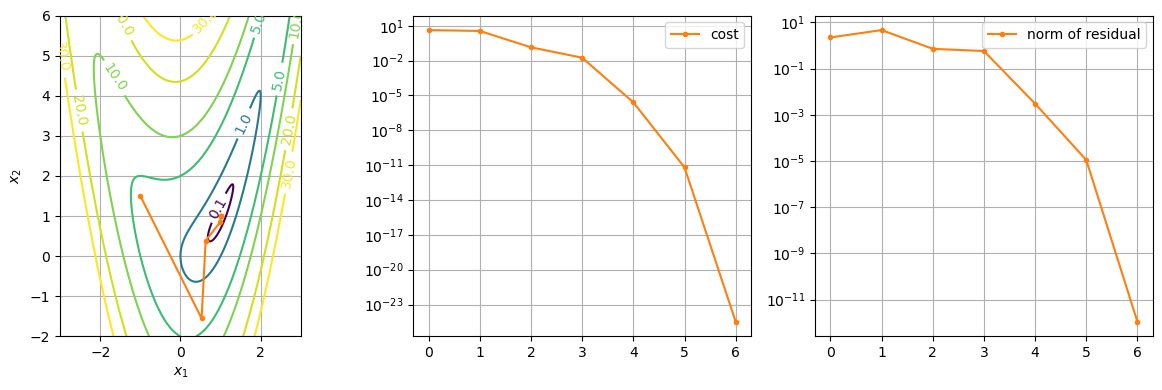

In [12]:
# Choose initial guess and compute cost and residual
x = np.array([-1., 1.5])
res = np.linalg.norm(f_x(x))
cost = f(x)

# Create log to keep track of convergence
log = {
    'x': [x],
    'res': [res],
    'cost': [cost],
}

# Choose parameters
max_iters = 500
max_inner_iters = 50
tol = 1e-8
c = 1e-4
rho = 0.5
delta = 1e-6
show_line_search = False

# Iterate
alpha = None
H = None
success = False
for i in range(max_iters):
    # Show progress
    print(f'{i:3d} : cost = {cost:7.4f} : res = {res:11.8f}' + (f' : alpha = {alpha:10.8f}' if alpha is not None else ''))

    # Check stopping condition (residual)
    if res < tol:
        success = True
        if i == 0:
            print(f'success (initial guess satisfies necessary conditions for optimality)')
        else:
            print(f'success (converged at iteration {i})')
        break
    
    # Choose descent direction (Newton step with regularization)
    # - Compute gradient and hessian
    grad_f = f_x(x)
    hess_f = f_xx(x)
    # - Regularize hessian if necessary to make it positive definite
    H = hess_f.copy()
    mu = delta
    while True:
        try:
            # Attempt a Cholesky factorization - if it fails, then H is not
            # positive definite and we need to add more regularization
            L_chol = np.linalg.cholesky(H)
            # Attempt to solve for the descent direction - if it fails, then
            # H is ill-conditioned and we need to add more regularization
            p = np.linalg.solve(H, -grad_f)
            break
        except np.linalg.LinAlgError:
            H = H + mu * np.eye(len(x))
            mu *= 10
    
    # Apply backtracking line search
    alpha = 1.
    no_progress = True
    for i_inner in range(max_inner_iters):
        if show_line_search:
            print(f' {i_inner:3d} : {alpha:5.3f} : {f(x + alpha * p):9.6f} : {c * alpha * f_x(x) * p:9.6f}')
        if f(x + alpha * p) <= f(x) + c * alpha * np.dot(grad_f, p):
            no_progress = False
            break
        else:
            alpha *= rho
    
    # Check stopping condition (no progress)
    if no_progress:
        print(f'failure (no progress at iteration {i})')
        break

    # Update guess
    x = x + alpha * p
    res = np.linalg.norm(f_x(x))
    cost = f(x)

    # Update log
    log['x'].append(x)
    log['res'].append(res)
    log['cost'].append(cost)

# Check if max iters was exceeded
if (not success) and (i == max_iters):
    print(f'failure (exceeded maximum number {max_iters} of iterations)')

# Clean log
for k in log.keys():
    log[k] = np.array(log[k])
log_newtonmethod = log

# Visualize results
# - Figure
fig, (ax2d, axf, axres) = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
# - Function
x1_bnds = [-3, 3]
x2_bnds = [-2, 6]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)
# - Iterations
x_iters = np.array(log['x'])
f_iters = np.array(log['cost'])
res_iters = np.array(log['res'])
ax2d.plot(x_iters[:, 0], x_iters[:, 1], '.-', color='C1', markersize=6)
axf.semilogy(f_iters, color='C1', label=r'cost', marker='.', markersize=6)
axres.semilogy(res_iters, color='C1', label=r'norm of residual', marker='.', markersize=6)
# - Appearance
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
axf.grid()
axf.legend()
axres.grid()
axres.legend()
plt.show()

How important was the Newton step? Try the same solver but choose the negative gradient as the descent direction.

  0 : cost =  4.2500 : res =  2.23606798
  1 : cost =  0.2500 : res =  2.23606798 : alpha = 1.00000000
  2 : cost =  0.0664 : res =  0.69877124 : alpha = 0.12500000
  3 : cost =  0.0349 : res =  0.18119134 : alpha = 0.12500000
  4 : cost =  0.0198 : res =  0.41546268 : alpha = 1.00000000
  5 : cost =  0.0108 : res =  0.13371325 : alpha = 0.12500000
  6 : cost =  0.0096 : res =  0.17653130 : alpha = 0.25000000
  7 : cost =  0.0077 : res =  0.08931039 : alpha = 0.12500000
  8 : cost =  0.0068 : res =  0.20574480 : alpha = 0.50000000
  9 : cost =  0.0047 : res =  0.08621880 : alpha = 0.12500000
 10 : cost =  0.0043 : res =  0.11975344 : alpha = 0.25000000
 11 : cost =  0.0034 : res =  0.06242171 : alpha = 0.12500000
 12 : cost =  0.0030 : res =  0.07868286 : alpha = 0.25000000
 13 : cost =  0.0029 : res =  0.12042870 : alpha = 0.25000000
 14 : cost =  0.0022 : res =  0.05858522 : alpha = 0.12500000
 15 : cost =  0.0020 : res =  0.08531404 : alpha = 0.25000000
 16 : cost =  0.0016 : res = 

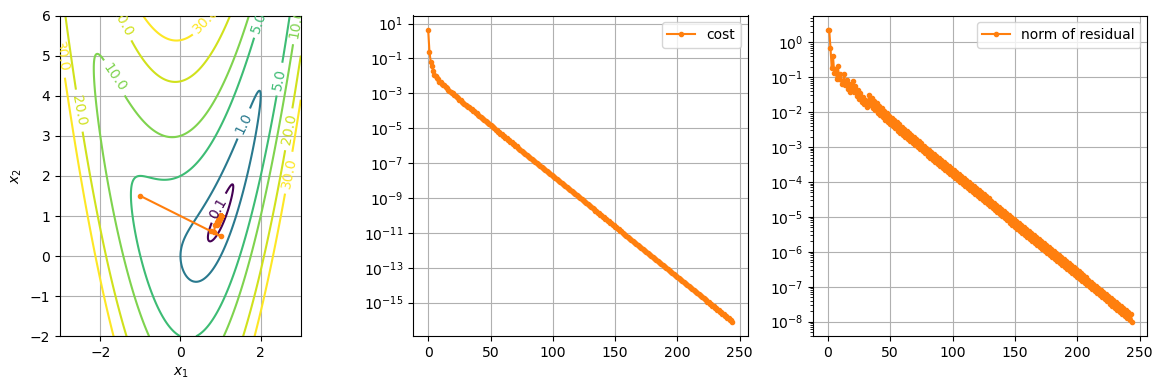

In [13]:
# Choose initial guess and compute cost and residual
x = log_newtonmethod['x'][0]          # <-- same initial guess as for Newton's method
res = np.linalg.norm(f_x(x))
cost = f(x)

# Create log to keep track of convergence
log = {
    'x': [x],
    'res': [res],
    'cost': [cost],
}

# Choose parameters
max_iters = 500
max_inner_iters = 100
tol = 1e-8
c = 1e-4
rho = 0.5
show_line_search = False

# Iterate
alpha = None
H = None
success = False
for i in range(max_iters):
    # Show progress
    print(f'{i:3d} : cost = {cost:7.4f} : res = {res:11.8f}' + (f' : alpha = {alpha:10.8f}' if alpha is not None else ''))

    # Check stopping condition (residual)
    if res < tol:
        success = True
        if i == 0:
            print(f'success (initial guess satisfies necessary conditions for optimality)')
        else:
            print(f'success (converged at iteration {i})')
        break
    
    # Choose descent direction (negative gradient)
    grad_f = f_x(x)
    p = -grad_f
    
    # Apply backtracking line search
    alpha = 1.
    no_progress = True
    for i_inner in range(max_inner_iters):
        if show_line_search:
            print(f' {i_inner:3d} : {alpha:5.3f} : {f(x + alpha * p):9.6f} : {c * alpha * f_x(x) * p:9.6f}')
        if f(x + alpha * p) <= f(x) + c * alpha * np.dot(grad_f, p):
            no_progress = False
            break
        else:
            alpha *= rho
    
    # Check stopping condition (no progress)
    if no_progress:
        print(f'failure (no progress at iteration {i})')
        break

    # Update guess
    x = x + alpha * p
    res = np.linalg.norm(f_x(x))
    cost = f(x)

    # Update log
    log['x'].append(x)
    log['res'].append(res)
    log['cost'].append(cost)

# Check if max iters was exceeded
if (not success) and (i == max_iters):
    print(f'failure (exceeded maximum number {max_iters} of iterations)')

# Clean log
for k in log.keys():
    log[k] = np.array(log[k])
log_gradientdescent = log

# Visualize results
# - Figure
fig, (ax2d, axf, axres) = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
# - Function
x1_bnds = [-3, 3]
x2_bnds = [-2, 6]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)
# - Iterations
x_iters = np.array(log['x'])
f_iters = np.array(log['cost'])
res_iters = np.array(log['res'])
ax2d.plot(x_iters[:, 0], x_iters[:, 1], '.-', color='C1', markersize=6)
axf.semilogy(f_iters, color='C1', label=r'cost', marker='.', markersize=6)
axres.semilogy(res_iters, color='C1', label=r'norm of residual', marker='.', markersize=6)
# - Appearance
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
axf.grid()
axf.legend()
axres.grid()
axres.legend()
plt.show()

Compare gradient descent with Newton's method.

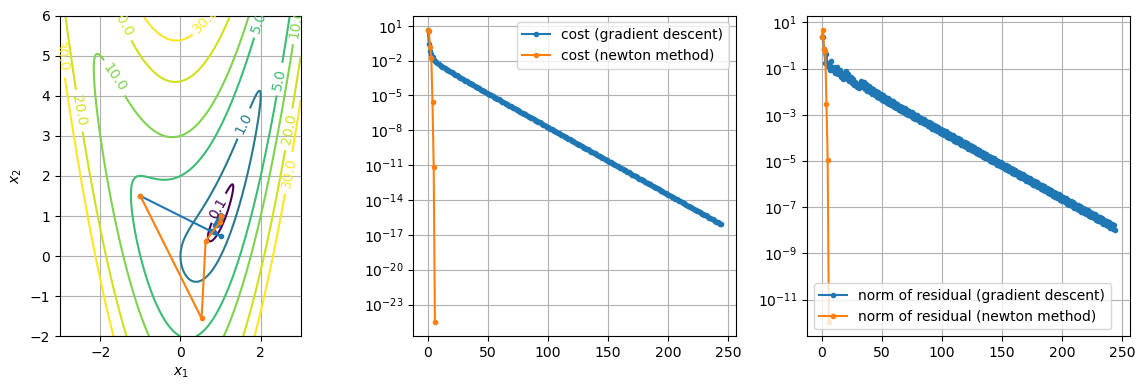

In [14]:
# Figure
fig, (ax2d, axf, axres) = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

# Function
x1_bnds = [-3, 3]
x2_bnds = [-2, 6]
X1, X2 = np.meshgrid(
    np.linspace(*x1_bnds, 500),
    np.linspace(*x2_bnds, 500),
)
F = f_batch(X1, X2)
CS = ax2d.contour(X1, X2, F, levels=[0.1, 1., 5., 10., 20., 30.], norm='log', cmap='viridis')
ax2d.clabel(CS, fontsize=10)

# Iterations
x_iters_gradientdescent = np.array(log_gradientdescent['x'])
f_iters_gradientdescent = np.array(log_gradientdescent['cost'])
res_iters_gradientdescent = np.array(log_gradientdescent['res'])
x_iters_newtonmethod = np.array(log_newtonmethod['x'])
f_iters_newtonmethod = np.array(log_newtonmethod['cost'])
res_iters_newtonmethod = np.array(log_newtonmethod['res'])
ax2d.plot(x_iters_gradientdescent[:, 0], x_iters_gradientdescent[:, 1], '.-', color='C0', markersize=6)
ax2d.plot(x_iters_newtonmethod[:, 0], x_iters_newtonmethod[:, 1], '.-', color='C1', markersize=6)
axf.semilogy(f_iters_gradientdescent, color='C0', label=r'cost (gradient descent)', marker='.', markersize=6)
axf.semilogy(f_iters_newtonmethod, color='C1', label=r'cost (newton method)', marker='.', markersize=6)
axres.semilogy(res_iters_gradientdescent, color='C0', label=r'norm of residual (gradient descent)', marker='.', markersize=6)
axres.semilogy(res_iters_newtonmethod, color='C1', label=r'norm of residual (newton method)', marker='.', markersize=6)

# Clean up
ax2d.grid()
ax2d.set_xlabel(r'$x_1$')
ax2d.set_ylabel(r'$x_2$')
ax2d.set_xlim(*x1_bnds)
ax2d.set_ylim(*x2_bnds)
ax2d.set_aspect('equal')
axf.grid()
axf.legend()
axres.grid()
axres.legend()
plt.show()